# Demo of DISC tomography based on a continental test.

## Description
This notebook implements DISC based ona continental test.
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.interpolate import RectBivariateSpline
import pyekfmm as fmm

address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

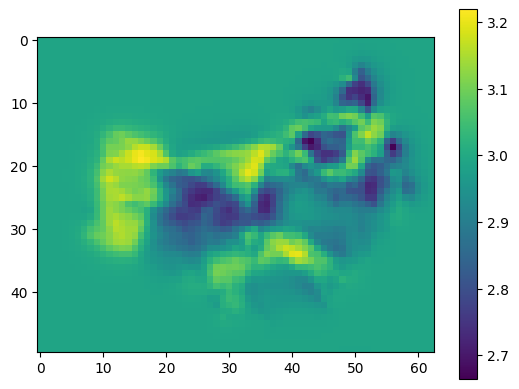

In [2]:
#####Step2 create real Marmousi model
address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

vel1=address+'/data/vsmooth5063.bin'
fd = open(vel1,'rb')
vel = np.fromfile(fd, dtype = np.float32).reshape([50,63],order='F')    #[rtp]
vel1d=vel.flatten(order='F');
# [r,t,p], r is radius, t is lat, p is lon 
# in 2D surface case, first axis is lat, second axis is lon, required by pyekfmm


plt.imshow(vel)
plt.colorbar()

In [3]:
## specify parameters
deg2km=6371*2*np.pi/360.0
x0=109;
dx=0.75;
z0=-46;
dz=0.75;
nx=63;
nz=50;

x=[(x0+i*dx) for i in range(nx)]
z=[(z0+i*dz) for i in range(nz)]


## maximum lon and lat in km
xm=x0+dx*nx;
zm=z0+dz*nz;

traveltime=address+'/data/travel_time.dat'
pairs = np.loadtxt(traveltime)

print(pairs.shape)


(25899, 6)


tracing the 0 ray
tracing the 500 ray
tracing the 1000 ray
tracing the 1500 ray
tracing the 2000 ray
tracing the 2500 ray
tracing the 3000 ray
tracing the 3500 ray
tracing the 4000 ray
tracing the 4500 ray
tracing the 5000 ray
tracing the 5500 ray
tracing the 6000 ray
tracing the 6500 ray
tracing the 7000 ray
tracing the 7500 ray
tracing the 8000 ray
tracing the 8500 ray
tracing the 9000 ray
tracing the 9500 ray
tracing the 10000 ray
tracing the 10500 ray
tracing the 11000 ray
tracing the 11500 ray
tracing the 12000 ray
tracing the 12500 ray
tracing the 13000 ray
tracing the 13500 ray
tracing the 14000 ray
tracing the 14500 ray
tracing the 15000 ray
tracing the 15500 ray
tracing the 16000 ray
tracing the 16500 ray
tracing the 17000 ray
tracing the 17500 ray
tracing the 18000 ray
tracing the 18500 ray
tracing the 19000 ray
tracing the 19500 ray
tracing the 20000 ray
tracing the 20500 ray
tracing the 21000 ray
tracing the 21500 ray
tracing the 22000 ray
tracing the 22500 ray
tracing the 

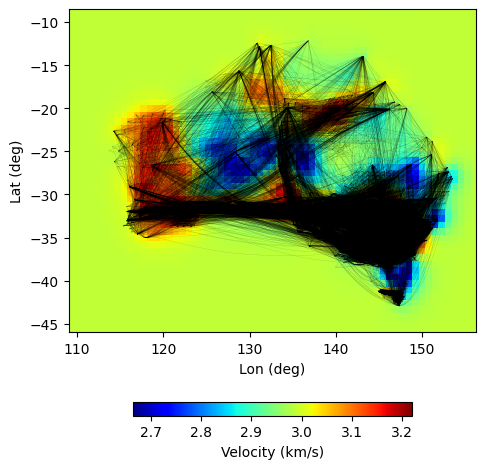

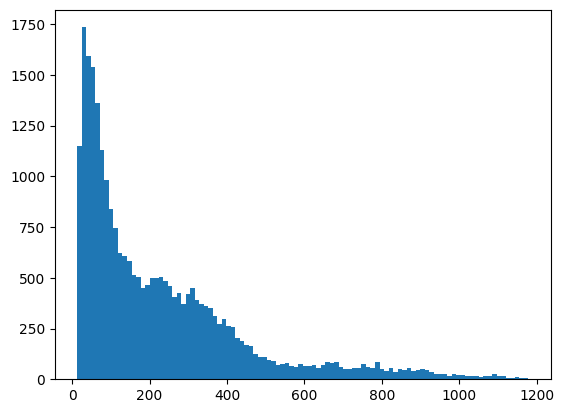

-1 1181.118525603552


In [4]:
## Read in event and station locations

fid=open('raypath.dat','w')
fid1=open('travel_time_syn.dat','w')
tt_pred =[]
tt_obs = []

ttmin=-1
ttmax=0


for i,p in enumerate(pairs):
    if i % 500 == 0:
        print(f'tracing the {i} ray')
    ## Event location in lat/lon
    elon=p[0];
    elat=p[1];
    ## Station location in lat/lon  
    slon=p[2]
    slat=p[3]

    ## Event and Station in km
    xe=elon;
    ze=elat;
    xs=slon;
    zs=slat;

    ## Traveltime calculation
#     t=fmm.eikonal(vel1d,xyz=np.array([xe,0,ze]),ax=[x0,dx,nx],ay=[0,0.01,1],az=[z0,dz,nz],order=2);
    t=fmm.eikonal_rtp(vel1d,rtp=np.array([6371,ze+90,xe+180]),ar=[6371,6371,1],at=[z0+90,dz,nz],ap=[x0+180,dx,nx],order=2); 
    time=t.reshape(nz,nx,order='F');#[r,t,p], r is radius, t is lat, p is lon
    
    # Extract the travel time at the station location
    f=RectBivariateSpline(z,x,time)
    tt=f(zs,xs).flatten()[0]
    tt_pred.append(tt)
    tt_obs.append(p[4])

    ttmin=min(tt,ttmin)
    ttmax=max(tt,ttmax)
    
    ## Ray tracing begins
    tz,tx = np.gradient(time)

    ## trace one ray (source and receiver locations are in decimal grids)
    stationx=(slon-x0)/0.75+1
    stationz=(slat-z0)/0.75+1
    eventx=(elon-x0)/0.75+1
    eventz=(elat-z0)/0.75+1

    ## key function: stream2d
    paths,nrays=stream2d_continent(-tx,-tz, stationx, stationz, step=0.1, maxvert=10000)
    ## trim the rays (remove redundant rays around source) and add the source point
    paths=trimrays_continent(paths,start_points=np.array([eventx,eventz]),T=0.2)
    
    # Save the ray paths and travel times as text files
    for px,pz in zip(paths[0],paths[1]):
        px=(px-1)*dx+x0
        pz=(pz-1)*dz+z0
        fid.write('{0:f} {1:f}\n'.format(px,pz))
    fid.write('{0:f} {1:f}\n'.format(np.nan,np.nan))   
    fid1.write('{0:f} {1:f} {2:f} {3:f} {4:f}\n'.format(elon,elat,slon,slat,tt))
    
    ## Visualization
    if i == 0:
        fig = plt.figure(figsize=(6, 6))
        ax=plt.subplot(1,1,1)
        plt.imshow(vel,cmap=plt.cm.jet, interpolation='none', extent=[x0,xm,zm,z0]); 
        ax.set_xlabel('Lon (deg)');
        ax.set_ylabel('Lat (deg)');
        plt.colorbar(orientation='horizontal',shrink=0.6,label='Velocity (km/s)');
        plt.gca().invert_yaxis()
    # mark event and station locations
    # ax1.plot(xe,ze,'*r',markersize=10)
    # ax1.plot(xs,zs,'vb',markersize=10)
    # plot the ray
    ax.plot((paths[0,:]-1)*dx+x0,(paths[1,:]-1)*dz+z0,
              'k',linewidth=0.1,alpha=0.4);
# plt.savefig('test_16_tomo_rays2.png',format='png',dpi=300,bbox_inches='tight', pad_inches=0)
plt.show()
fid.close()
fid1.close()

# Plot difference between observed and predicted travel times
plt.figure()
plt.hist(np.asarray(tt_pred)-np.asarray(tt_obs),100)
# plt.savefig('test_16_tomo_rays_hist2.png',format='png',dpi=300,bbox_inches='tight', pad_inches=0)
plt.show()


print(ttmin,ttmax)